Using device: cpu


100%|██████████| 26.4M/26.4M [00:02<00:00, 8.92MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 143kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.71MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.5MB/s]


Train: 1600, Validation: 400, Test: 800


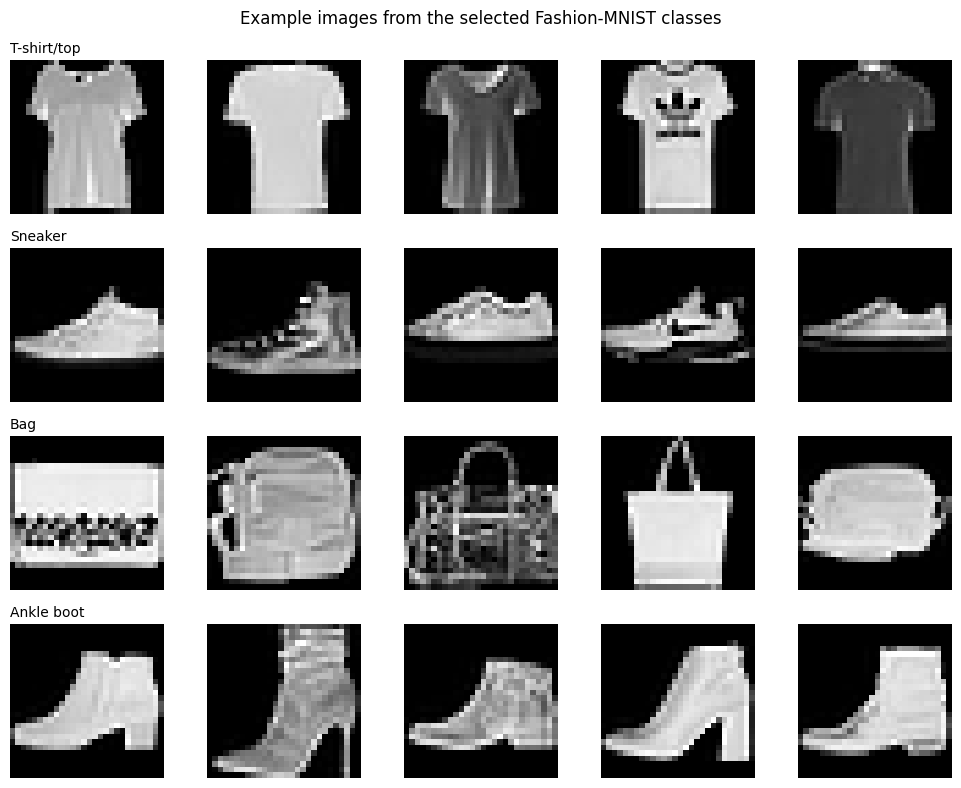

Epoch 1/5 | random | loss=0.0693
Epoch 2/5 | random | loss=0.0295
Epoch 3/5 | random | loss=0.0226
Epoch 4/5 | random | loss=0.0185
Epoch 5/5 | random | loss=0.0106
Epoch 1/5 | semi-hard | loss=0.1885
Epoch 2/5 | semi-hard | loss=0.0974
Epoch 3/5 | semi-hard | loss=0.0460
Epoch 4/5 | semi-hard | loss=0.0192
Epoch 5/5 | semi-hard | loss=0.0039


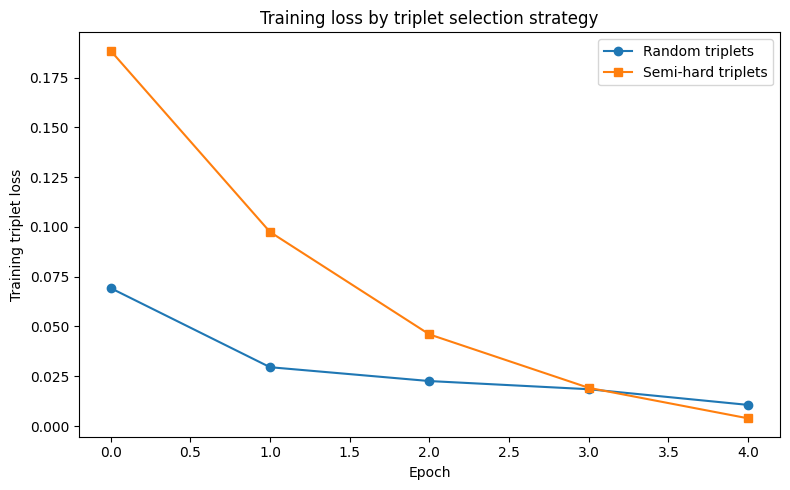

k-NN accuracy (random):    0.9650
k-NN accuracy (semi-hard): 0.9700


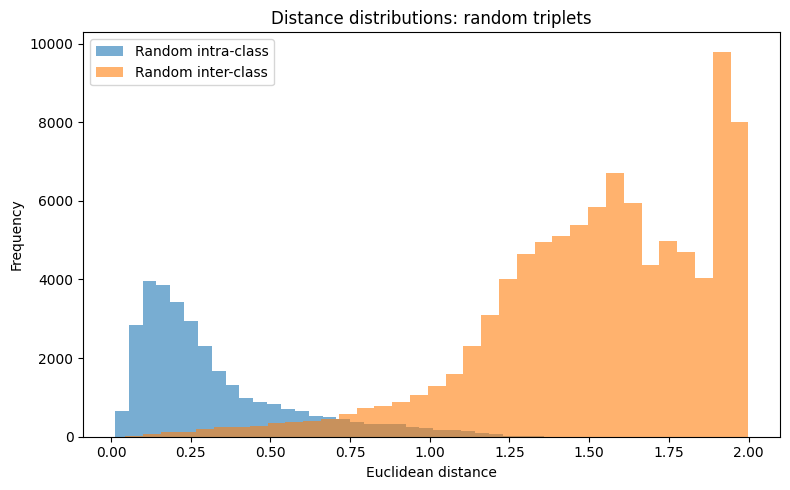

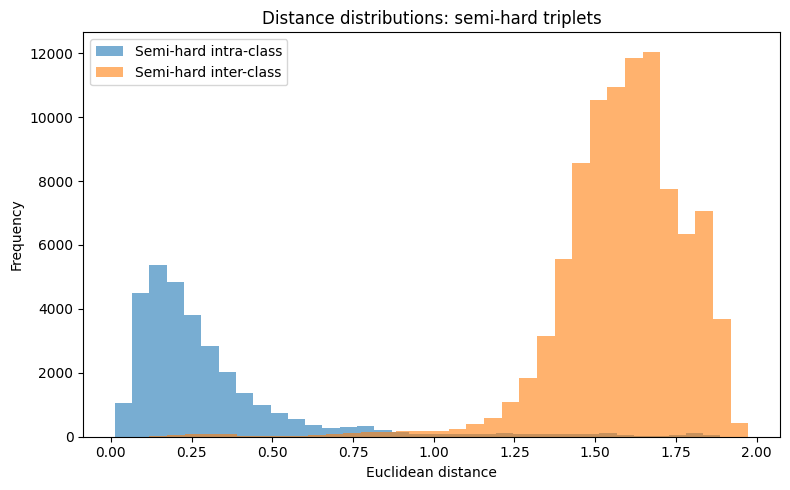

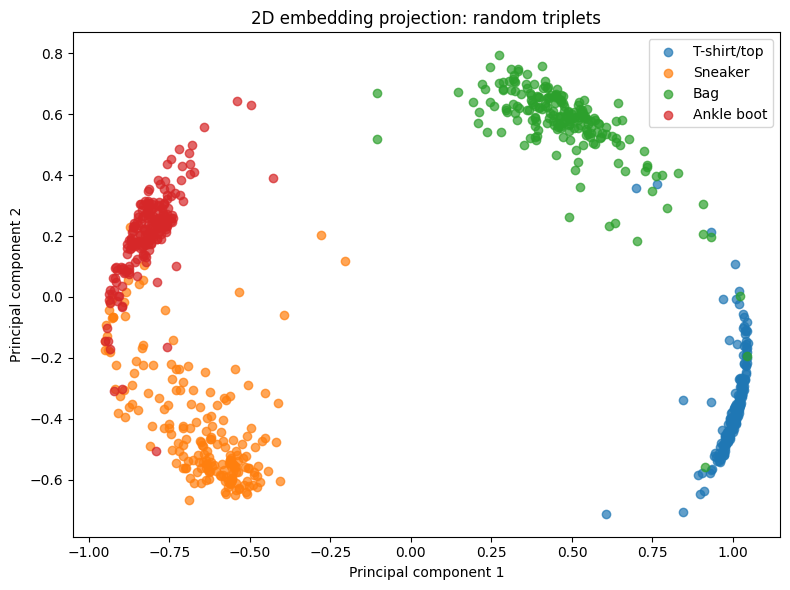

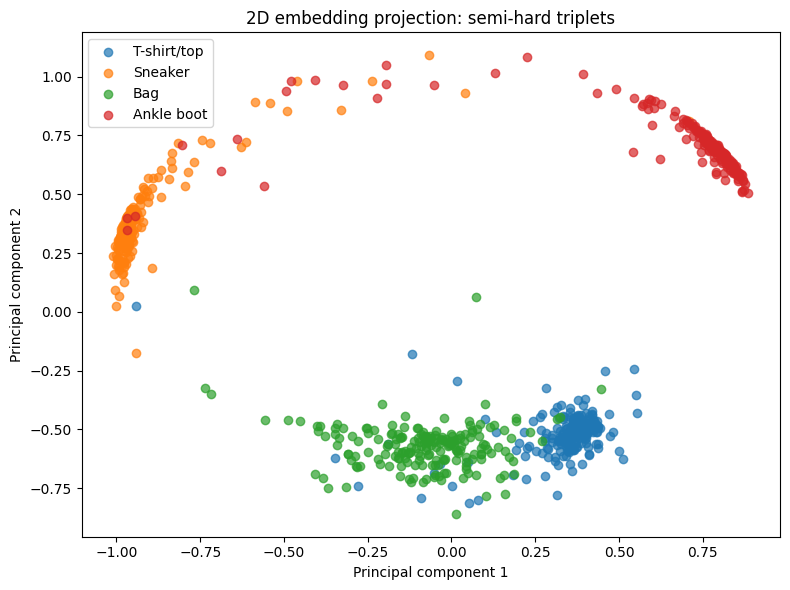


Summary results:


,Strategy,kNN Accuracy,Mean Intra-class Distance,Mean Inter-class Distance
0,Random triplets,0.965,0.3204,1.5264
1,Semi-hard triplets,0.970,0.3100,1.5876



Suggested report interpretation:
Semi-hard triplet mining is expected to produce better embeddings because it avoids
wasting training effort on trivially easy negatives. If the semi-hard model shows
higher k-NN accuracy, tighter intra-class distances, and better visual separation
in PCA space, that supports the claim that triplet quality strongly affects
embedding quality.


In [1]:
# ============================================================
# ONE-CELL NOTEBOOK: Triplet Loss Tutorial
# Topic: How Triplet Selection Changes Embedding Quality
# Fast version: compares Random vs Semi-hard triplet selection
# ============================================================
#
# Notes:
# - Designed to run in reasonable time on average hardware
# - Uses a subset of Fashion-MNIST classes and samples
# - Keeps the model small and epochs low
# - Produces tutorial-ready plots and summary metrics
#
# Suggested report use:
# - Figure 1: sample images
# - Figure 2: training loss comparison
# - Figure 3: 2D embedding comparison
# - Figure 4: distance distribution comparison
# - Table 1: summary metrics
# ============================================================

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

# -----------------------------
# 1. Reproducibility and device
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# 2. Config: keep runtime modest
# -----------------------------
selected_classes = [0, 7, 8, 9]   # T-shirt/top, Sneaker, Bag, Ankle boot
class_names = {
    0: "T-shirt/top",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}

MAX_TRAIN_PER_CLASS = 500   # keep training small for speed
MAX_TEST_PER_CLASS  = 200
EMBED_DIM = 8
BATCH_SIZE = 64
EPOCHS = 5
ITERATIONS_PER_EPOCH = 40   # lower for faster runtime
LR = 1e-3
MARGIN = 0.5
MINING_SUBSET = 256         # subset used for semi-hard mining
EVAL_SAMPLE_LIMIT = 500     # limit pairwise distance cost

# -----------------------------
# 3. Load and filter dataset
# -----------------------------
transform = transforms.Compose([transforms.ToTensor()])

train_full = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
test_full  = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

def filter_and_limit_dataset(dataset, selected_classes, max_per_class):
    """
    Keep only selected classes and cap the number of samples per class
    to reduce runtime while preserving class balance.
    """
    class_counts = {cls: 0 for cls in selected_classes}
    images, labels = [], []

    for img, label in dataset:
        if label in selected_classes and class_counts[label] < max_per_class:
            images.append(img)
            labels.append(label)
            class_counts[label] += 1

        if all(class_counts[c] >= max_per_class for c in selected_classes):
            break

    return images, labels

train_images, train_labels = filter_and_limit_dataset(train_full, selected_classes, MAX_TRAIN_PER_CLASS)
test_images, test_labels   = filter_and_limit_dataset(test_full, selected_classes, MAX_TEST_PER_CLASS)

train_idx, val_idx = train_test_split(
    np.arange(len(train_images)),
    test_size=0.2,
    random_state=SEED,
    stratify=train_labels
)

train_imgs = [train_images[i] for i in train_idx]
train_labs = [train_labels[i] for i in train_idx]

val_imgs = [train_images[i] for i in val_idx]
val_labs = [train_labels[i] for i in val_idx]

print(f"Train: {len(train_imgs)}, Validation: {len(val_imgs)}, Test: {len(test_images)}")

# -----------------------------
# 4. Show sample images
# -----------------------------
def show_class_examples(images, labels, class_names, selected_classes, samples_per_class=5):
    fig, axes = plt.subplots(len(selected_classes), samples_per_class, figsize=(10, 8))
    for row, cls in enumerate(selected_classes):
        cls_indices = [i for i, lab in enumerate(labels) if lab == cls][:samples_per_class]
        for col, idx in enumerate(cls_indices):
            axes[row, col].imshow(images[idx].squeeze().numpy(), cmap="gray")
            axes[row, col].axis("off")
            if col == 0:
                axes[row, col].set_title(class_names[cls], loc="left", fontsize=10)
    plt.suptitle("Example images from the selected Fashion-MNIST classes")
    plt.tight_layout()
    plt.show()

show_class_examples(train_imgs, train_labs, class_names, selected_classes)

# -----------------------------
# 5. Encoder model
# -----------------------------
class SimpleCNNEncoder(nn.Module):
    """
    Small CNN that maps an image to a normalized embedding vector.
    """
    def __init__(self, embedding_dim=8):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 64),
            nn.ReLU(),
            nn.Linear(64, embedding_dim)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.fc(x)
        x = F.normalize(x, p=2, dim=1)
        return x

# -----------------------------
# 6. Triplet loss
# -----------------------------
class TripletLoss(nn.Module):
    """
    Standard triplet loss:
    makes anchor-positive distance smaller than anchor-negative distance
    by at least the margin.
    """
    def __init__(self, margin=0.5):
        super().__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative):
        pos_dist = F.pairwise_distance(anchor, positive)
        neg_dist = F.pairwise_distance(anchor, negative)
        return F.relu(pos_dist - neg_dist + self.margin).mean()

# -----------------------------
# 7. Triplet sampling helpers
# -----------------------------
def build_label_index(labels):
    label_to_indices = defaultdict(list)
    for idx, label in enumerate(labels):
        label_to_indices[label].append(idx)
    return label_to_indices

def sample_random_triplet(images, labels, label_to_indices):
    """
    Random triplet:
    anchor and positive share a class; negative is from another class.
    """
    anchor_idx = random.randint(0, len(images) - 1)
    anchor_label = labels[anchor_idx]
    positive_idx = anchor_idx
    while positive_idx == anchor_idx:
        positive_idx = random.choice(label_to_indices[anchor_label])

    negative_label = random.choice([lab for lab in label_to_indices.keys() if lab != anchor_label])
    negative_idx = random.choice(label_to_indices[negative_label])

    return images[anchor_idx], images[positive_idx], images[negative_idx]

def create_random_triplet_batch(images, labels, batch_size=64):
    label_to_indices = build_label_index(labels)
    anchors, positives, negatives = [], [], []
    for _ in range(batch_size):
        a, p, n = sample_random_triplet(images, labels, label_to_indices)
        anchors.append(a)
        positives.append(p)
        negatives.append(n)
    return torch.stack(anchors), torch.stack(positives), torch.stack(negatives)

def pairwise_distances(embeddings):
    """
    Efficient pairwise Euclidean distance matrix.
    """
    dot_product = torch.matmul(embeddings, embeddings.t())
    square_norm = torch.diag(dot_product)
    distances = square_norm.unsqueeze(1) - 2 * dot_product + square_norm.unsqueeze(0)
    distances = torch.clamp(distances, min=0.0)
    return torch.sqrt(distances + 1e-8)

def mine_semi_hard_triplets(model, images, labels, margin=0.5, num_triplets=64, subset_size=256):
    """
    Semi-hard triplet mining on a random subset for speed.
    Semi-hard negatives satisfy:
        positive distance < negative distance < positive distance + margin
    """
    model.eval()

    subset_size = min(subset_size, len(images))
    subset_indices = np.random.choice(len(images), subset_size, replace=False)
    batch_imgs = torch.stack([images[i] for i in subset_indices]).to(device)
    batch_labels = torch.tensor([labels[i] for i in subset_indices]).to(device)

    with torch.no_grad():
        embeds = model(batch_imgs)

    dist_matrix = pairwise_distances(embeds)
    triplets = []

    for i in range(subset_size):
        anchor_label = batch_labels[i].item()

        positive_candidates = torch.where(batch_labels == anchor_label)[0]
        positive_candidates = positive_candidates[positive_candidates != i]
        negative_candidates = torch.where(batch_labels != anchor_label)[0]

        if len(positive_candidates) == 0 or len(negative_candidates) == 0:
            continue

        pos_idx = positive_candidates[torch.randint(len(positive_candidates), (1,)).item()]
        pos_dist = dist_matrix[i, pos_idx].item()

        semi_hard_negatives = []
        for neg_idx in negative_candidates:
            neg_dist = dist_matrix[i, neg_idx].item()
            if pos_dist < neg_dist < pos_dist + margin:
                semi_hard_negatives.append(neg_idx.item())

        if len(semi_hard_negatives) > 0:
            neg_idx = random.choice(semi_hard_negatives)
            triplets.append((
                batch_imgs[i].cpu(),
                batch_imgs[pos_idx].cpu(),
                batch_imgs[neg_idx].cpu()
            ))

        if len(triplets) >= num_triplets:
            break

    return triplets

# -----------------------------
# 8. Training loop
# -----------------------------
def train_model(model, images, labels, strategy="random", epochs=5, batch_size=64,
                iterations_per_epoch=40, lr=1e-3, margin=0.5, mining_subset=256):
    """
    Train one model under one triplet selection strategy.
    The only intended change between experiments is the mining strategy.
    """
    model = model.to(device)
    criterion = TripletLoss(margin=margin)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": []}

    for epoch in range(epochs):
        model.train()
        epoch_losses = []

        for _ in range(iterations_per_epoch):
            if strategy == "random":
                anchors, positives, negatives = create_random_triplet_batch(images, labels, batch_size=batch_size)

            elif strategy == "semi-hard":
                mined_triplets = mine_semi_hard_triplets(
                    model, images, labels,
                    margin=margin,
                    num_triplets=batch_size,
                    subset_size=mining_subset
                )

                # Fallback to random if too few semi-hard triplets are found
                if len(mined_triplets) < batch_size:
                    anchors, positives, negatives = create_random_triplet_batch(images, labels, batch_size=batch_size)
                else:
                    anchors = torch.stack([t[0] for t in mined_triplets])
                    positives = torch.stack([t[1] for t in mined_triplets])
                    negatives = torch.stack([t[2] for t in mined_triplets])
            else:
                raise ValueError("strategy must be 'random' or 'semi-hard'")

            anchors = anchors.to(device)
            positives = positives.to(device)
            negatives = negatives.to(device)

            optimizer.zero_grad()
            anchor_emb = model(anchors)
            positive_emb = model(positives)
            negative_emb = model(negatives)

            loss = criterion(anchor_emb, positive_emb, negative_emb)
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())

        mean_loss = float(np.mean(epoch_losses))
        history["train_loss"].append(mean_loss)
        print(f"Epoch {epoch+1}/{epochs} | {strategy} | loss={mean_loss:.4f}")

    return model, history

# -----------------------------
# 9. Train both models
# -----------------------------
random_model = SimpleCNNEncoder(embedding_dim=EMBED_DIM)
random_model, random_history = train_model(
    random_model, train_imgs, train_labs,
    strategy="random",
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    iterations_per_epoch=ITERATIONS_PER_EPOCH,
    lr=LR,
    margin=MARGIN,
    mining_subset=MINING_SUBSET
)

semi_model = SimpleCNNEncoder(embedding_dim=EMBED_DIM)
semi_model, semi_history = train_model(
    semi_model, train_imgs, train_labs,
    strategy="semi-hard",
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    iterations_per_epoch=ITERATIONS_PER_EPOCH,
    lr=LR,
    margin=MARGIN,
    mining_subset=MINING_SUBSET
)

# -----------------------------
# 10. Plot training loss
# -----------------------------
plt.figure(figsize=(8, 5))
plt.plot(random_history["train_loss"], marker="o", label="Random triplets")
plt.plot(semi_history["train_loss"], marker="s", label="Semi-hard triplets")
plt.xlabel("Epoch")
plt.ylabel("Training triplet loss")
plt.title("Training loss by triplet selection strategy")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 11. Extract embeddings
# -----------------------------
def extract_embeddings(model, images, labels):
    """
    Convert all images to embedding vectors for evaluation.
    """
    model.eval()
    all_embeddings, all_labels = [], []

    with torch.no_grad():
        for img, label in zip(images, labels):
            emb = model(img.unsqueeze(0).to(device))
            all_embeddings.append(emb.squeeze(0).cpu().numpy())
            all_labels.append(label)

    return np.array(all_embeddings), np.array(all_labels)

train_random_embeds, train_random_labels = extract_embeddings(random_model, train_imgs, train_labs)
test_random_embeds,  test_random_labels  = extract_embeddings(random_model, test_images, test_labels)

train_semi_embeds, train_semi_labels = extract_embeddings(semi_model, train_imgs, train_labs)
test_semi_embeds,  test_semi_labels  = extract_embeddings(semi_model, test_images, test_labels)

# -----------------------------
# 12. k-NN evaluation
# -----------------------------
def evaluate_knn(train_embeds, train_labels, test_embeds, test_labels, k=5):
    """
    Evaluate embedding usefulness using k-NN in embedding space.
    """
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(train_embeds, train_labels)
    preds = knn.predict(test_embeds)
    return accuracy_score(test_labels, preds)

random_knn_acc = evaluate_knn(train_random_embeds, train_random_labels, test_random_embeds, test_random_labels)
semi_knn_acc   = evaluate_knn(train_semi_embeds, train_semi_labels, test_semi_embeds, test_semi_labels)

print(f"k-NN accuracy (random):    {random_knn_acc:.4f}")
print(f"k-NN accuracy (semi-hard): {semi_knn_acc:.4f}")

# -----------------------------
# 13. Distance statistics
# -----------------------------
def compute_distance_statistics(embeddings, labels, sample_limit=500):
    """
    Compute intra-class and inter-class distances.
    Uses a capped sample for speed.
    """
    if len(embeddings) > sample_limit:
        idx = np.random.choice(len(embeddings), sample_limit, replace=False)
        embeddings = embeddings[idx]
        labels = labels[idx]

    intra_dists, inter_dists = [], []
    n = len(embeddings)

    for i in range(n):
        for j in range(i + 1, n):
            dist = np.linalg.norm(embeddings[i] - embeddings[j])
            if labels[i] == labels[j]:
                intra_dists.append(dist)
            else:
                inter_dists.append(dist)

    return np.array(intra_dists), np.array(inter_dists)

random_intra, random_inter = compute_distance_statistics(test_random_embeds, test_random_labels, sample_limit=EVAL_SAMPLE_LIMIT)
semi_intra, semi_inter     = compute_distance_statistics(test_semi_embeds, test_semi_labels, sample_limit=EVAL_SAMPLE_LIMIT)

# -----------------------------
# 14. Distance distribution plots
# -----------------------------
plt.figure(figsize=(8, 5))
plt.hist(random_intra, bins=35, alpha=0.6, label="Random intra-class")
plt.hist(random_inter, bins=35, alpha=0.6, label="Random inter-class")
plt.xlabel("Euclidean distance")
plt.ylabel("Frequency")
plt.title("Distance distributions: random triplets")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(semi_intra, bins=35, alpha=0.6, label="Semi-hard intra-class")
plt.hist(semi_inter, bins=35, alpha=0.6, label="Semi-hard inter-class")
plt.xlabel("Euclidean distance")
plt.ylabel("Frequency")
plt.title("Distance distributions: semi-hard triplets")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 15. 2D embedding visualization
# -----------------------------
def plot_embeddings_2d(embeddings, labels, class_names, selected_classes, title):
    """
    Use PCA to project embeddings to 2D for tutorial-friendly visualization.
    """
    reduced = PCA(n_components=2).fit_transform(embeddings)

    plt.figure(figsize=(8, 6))
    for cls in selected_classes:
        idx = labels == cls
        plt.scatter(
            reduced[idx, 0],
            reduced[idx, 1],
            label=class_names[cls],
            alpha=0.7
        )
    plt.xlabel("Principal component 1")
    plt.ylabel("Principal component 2")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_embeddings_2d(test_random_embeds, test_random_labels, class_names, selected_classes,
                   "2D embedding projection: random triplets")

plot_embeddings_2d(test_semi_embeds, test_semi_labels, class_names, selected_classes,
                   "2D embedding projection: semi-hard triplets")

# -----------------------------
# 16. Summary results table
# -----------------------------
results_df = pd.DataFrame({
    "Strategy": ["Random triplets", "Semi-hard triplets"],
    "kNN Accuracy": [random_knn_acc, semi_knn_acc],
    "Mean Intra-class Distance": [random_intra.mean(), semi_intra.mean()],
    "Mean Inter-class Distance": [random_inter.mean(), semi_inter.mean()]
})

print("\nSummary results:")
display(results_df.round(4))

# -----------------------------
# 17. Report-ready interpretation
# -----------------------------
print("\nSuggested report interpretation:")
print(
    "Semi-hard triplet mining is expected to produce better embeddings because it avoids\n"
    "wasting training effort on trivially easy negatives. If the semi-hard model shows\n"
    "higher k-NN accuracy, tighter intra-class distances, and better visual separation\n"
    "in PCA space, that supports the claim that triplet quality strongly affects\n"
    "embedding quality."
)